In [ ]:
import os
import tensorflow as tf
from tensorflow import keras

# PHASE 1: SETUP & VARIABLES

data_dir = r"Path-to-folder\Minor-project-DL-models\COVID-19_Radiography_Dataset"

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 123  

# PHASE 2: DATA SPLITTING & LOADING

print("--- Loading Datasets ---")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    label_mode='categorical',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_and_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    label_mode='categorical',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_batches = tf.data.experimental.cardinality(val_and_test_dataset)
validation_dataset = val_and_test_dataset.take(val_batches // 2)
test_dataset = val_and_test_dataset.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

--- Loading Datasets ---
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Found 21165 files belonging to 4 classes.
Using 4233 files for validation.


In [ ]:
# PHASE 3: DATA AUGMENTATION


data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomBrightness(factor=0.2),
    keras.layers.RandomContrast(factor=0.2)
], name="medical_augmentation_pipeline")

print("\n--- Data Augmentation Pipeline Ready ---")

# PHASE 4: CLINICALLY ADJUSTED CLASS WEIGHTS

print("\n--- Calculating Class Weights ---")

covid_dir = os.path.join(data_dir, "covid-19")
lung_opacity_dir = os.path.join(data_dir, "lung_opacity")
normal_dir = os.path.join(data_dir, "normal")
pneumonia_dir = os.path.join(data_dir, "pneumonia")

covid_count = len(os.listdir(covid_dir))
lung_opacity_count = len(os.listdir(lung_opacity_dir))
normal_count = len(os.listdir(normal_dir))
pneumonia_count = len(os.listdir(pneumonia_dir))

total_images = covid_count + lung_opacity_count + normal_count + pneumonia_count
num_classes = 4

base_covid = (1 / covid_count) * (total_images / num_classes)
base_opacity = (1 / lung_opacity_count) * (total_images / num_classes)
base_normal = (1 / normal_count) * (total_images / num_classes)
base_pneumonia = (1 / pneumonia_count) * (total_images / num_classes)

class_weights = {
    0: base_covid,
    1: base_opacity,
    2: base_normal,
    3: base_pneumonia
}

print(f"Total Images Processed: {total_images}")
print("Final Class Weights Dictionary:", class_weights)
print("\n✅ PIPELINE COMPLETE. READY FOR MODEL ARCHITECTURE.")


--- Data Augmentation Pipeline Ready ---

--- Calculating Class Weights ---
Total Images Processed: 21165
Final Class Weights Dictionary: {0: 1.4632881637168142, 1: 0.8801147704590818, 2: 0.5191571821036107, 3: 3.934014869888476}

✅ PIPELINE COMPLETE. READY FOR MODEL ARCHITECTURE.


In [ ]:
import tensorflow as tf
from tensorflow import keras

# PHASE 5:  DENSENET121 ARCHITECTURE

print("\n--- Initializing Transfer Learning Architectures ---")

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
x = data_augmentation(inputs)
x = tf.keras.applications.densenet.preprocess_input(x)
base_model = tf.keras.applications.DenseNet121(weights='imagenet', include_top=False, input_tensor=x)

base_model.trainable = False 
    
x = keras.layers.GlobalAveragePooling2D()(base_model.output)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.25)(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
    
densenet_model = keras.Model(inputs, outputs, name="DenseNet121_Medical")

densenet_model.summary()




--- Initializing Transfer Learning Architectures ---
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


Model: "DenseNet121_Medical"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ medical_augmentati… │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ medical_augmenta… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ true_divide_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r

 Total params: 7,169,220 (27.35 MB)

 Trainable params: 131,716 (514.52 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


def get_callbacks(model_name):

    checkpoint = ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    return [checkpoint, early_stopping]


# PHASE 6: COMPILATION & TRAINING

print("\n--- Compiling Model ---")

densenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("\n=== Building and Training DenseNet121 ===")


densenet_callbacks = get_callbacks("DenseNet121")

EPOCHS = 30

history_densenet = densenet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=densenet_callbacks
)

print("\n✅ PRE-TRAINED MODEL SUCCESSFULLY TRAINED AND SAVED.")
    


--- Compiling Model ---

=== Building and Training DenseNet121 ===
Epoch 1/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - accuracy: 0.6377 - auc: 0.8595 - loss: 0.7911
Epoch 1: val_auc improved from None to 0.94105, saving model to DenseNet121_best.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 572s 1s/step - accuracy: 0.7123 - auc: 0.9101 - loss: 0.6199 - val_accuracy: 0.7784 - val_auc: 0.9411 - val_loss: 0.5813
Epoch 2/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7671 - auc: 0.9395 - loss: 0.4911
Epoch 2: val_auc did not improve from 0.94105
530/530 ━━━━━━━━━━━━━━━━━━━━ 614s 1s/step - accuracy: 0.7736 - auc: 0.9420 - loss: 0.4793 - val_accuracy: 0.6780 - val_auc: 0.9036 - val_loss: 0.7537
Epoch 3/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.7887 - auc: 0.9501 - loss: 0.4342
Epoch 3: val_auc improved from 0.94105 to 0.96853, saving model to DenseNet121_best.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 588s 1s/step - accuracy: 0.7959 - auc: 0.9518 - loss: 0.4301 - val_accuracy: 


--- Step 1: Overall Testing Metrics ---

[ Evaluating DenseNet121 ]
67/67 ━━━━━━━━━━━━━━━━━━━━ 65s 959ms/step - accuracy: 0.8501 - auc: 0.9718 - loss: 0.4033
DenseNet Accuracy: 85.01% | AUC: 0.9718

--- Step 2: Generating Predictions for  Model ---
Predictions successfully generated.

--- Step 3: The Confusion Matrix ---


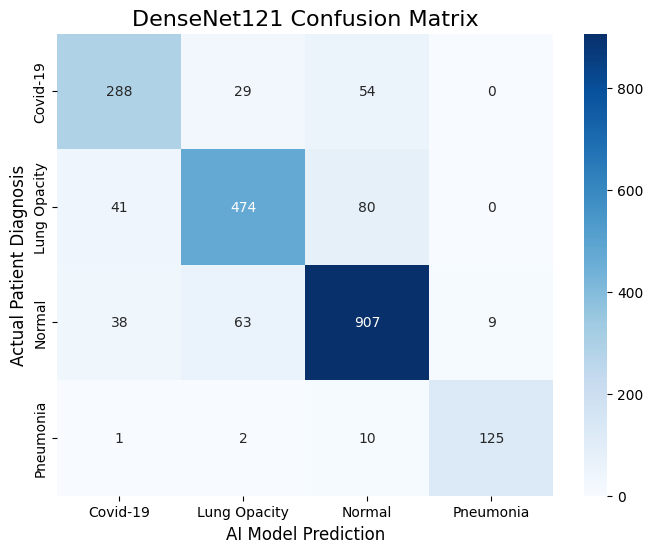


--- Step 4: Classification Report ---
              precision    recall  f1-score   support

    Covid-19       0.78      0.78      0.78       371
Lung Opacity       0.83      0.80      0.82       595
      Normal       0.86      0.89      0.88      1017
   Pneumonia       0.93      0.91      0.92       138

    accuracy                           0.85      2121
   macro avg       0.85      0.84      0.85      2121
weighted avg       0.85      0.85      0.85      2121



In [ ]:
# PHASE 7: EVALUATION & METRICS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n--- Step 1: Overall Testing Metrics ---")


print("\n[ Evaluating DenseNet121 ]")
dense_loss, dense_acc, dense_auc = densenet_model.evaluate(test_dataset)
print(f"DenseNet Accuracy: {dense_acc * 100:.2f}% | AUC: {dense_auc:.4f}")


print("\n--- Step 2: Generating Predictions for  Model ---")

y_true = []
y_pred_probs_dense = []

for images, labels in test_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))   
    y_pred_probs_dense.extend(densenet_model.predict(images, verbose=0))
       

y_pred_classes_dense = np.argmax(y_pred_probs_dense, axis=1)

print("Predictions successfully generated.")


# PHASE 8: VISUALIZING THE MISTAKES
print("\n--- Step 3: The Confusion Matrix ---")


class_names = ['Covid-19', 'Lung Opacity', 'Normal', 'Pneumonia']

cm = confusion_matrix(y_true, y_pred_classes_dense)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('DenseNet121 Confusion Matrix', fontsize=16)
plt.ylabel('Actual Patient Diagnosis', fontsize=12)
plt.xlabel('AI Model Prediction', fontsize=12)
plt.show()


# PHASE 9: THE CLINICAL REPORT
print("\n--- Step 4: Classification Report ---")
report = classification_report(y_true, y_pred_classes_dense, target_names=class_names)
print(report)


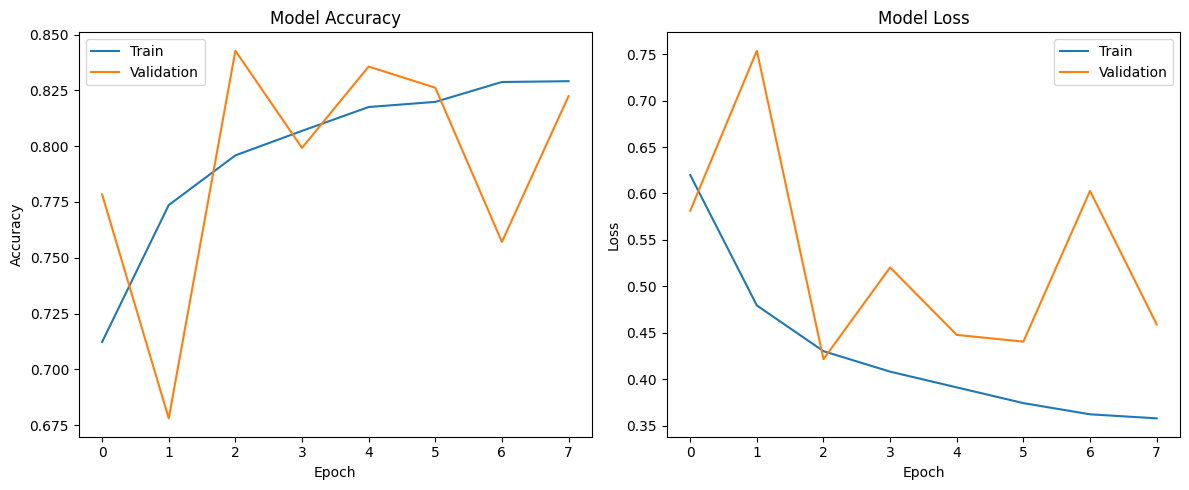

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_densenet.history['accuracy'])
plt.plot(history_densenet.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(history_densenet.history['loss'])
plt.plot(history_densenet.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

In [12]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

loaded_model = tf.keras.models.load_model("DenseNet121_best.keras")
print("Model loaded successfully!")

img_path = r"C:\Users\siddh\Documents\GitHub\Minor-project-DL-models\COVID-19_Radiography_Dataset\covid-19\COVID-28.png"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 

predictions = loaded_model.predict(img_array)

class_names = ['Covid', 'Lung Opacity', 'Normal', 'Pneumonia']
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100

print(f"Diagnosis: {class_names[predicted_class_index]}")
print(f"AI Confidence: {confidence:.2f}%")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Diagnosis: Covid
AI Confidence: 94.73%
